In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import img_as_float
from skimage.io import imread, imshow
from sklearn.cluster import KMeans

%matplotlib inline

1. Загрузите картинку parrots.jpg.
Преобразуйте изображение, приведя все значения в интервал от 0 до 1. Для этого можно воспользоваться функцией img_as_float из модуля skimage. Обратите внимание на этот шаг, так как при работе с исходным изображением вы получите некорректный результат.

In [3]:
image = img_as_float(imread("parrots.jpg"))


2. Создайте матрицу объекты-признаки: характеризуйте каждый пиксель тремя координатами - значениями интенсивности в пространстве RGB.

In [4]:
w, h, d = image.shape
pixels = pd.DataFrame(np.reshape(image, (w*h, d)), columns=["R", "G", "B"])
pixels.head()

,R,G,B
0,0.015686,0.494118,0.019608
1,0.011765,0.490196,0.015686
2,0.007843,0.494118,0.007843
3,0.007843,0.494118,0.007843
4,0.007843,0.501961,0.011765


3. Запустите алгоритм K-Means
с параметрами init='k-means++' и random_state=241. После выделения кластеров все пиксели, отнесенные в один кластер, попробуйте заполнить двумя способами: медианным и средним цветом по кластеру.

In [5]:
def cluster_pixels(pixels: pd.DataFrame, n_clusters: int=8):
    pixels = pixels.copy()

    model = KMeans(n_clusters=n_clusters, init="k-means++", random_state=241)
    pixels["cluster"] = model.fit_predict(pixels)

    return pixels

def mean_median_image(pixels: pd.DataFrame):
    means = pixels.groupby("cluster").mean().values
    mean_pixels = np.array([means[c] for c in pixels["cluster"]])
    mean_image = np.reshape(mean_pixels, (w, h, d))

    medians = pixels.groupby("cluster").median().values
    median_pixels = np.array([medians[c] for c in pixels["cluster"]])
    median_image = np.reshape(median_pixels, (w, h, d))

    return mean_image, median_image

4. Измерьте качество получившейся сегментации с помощью метрики PSNR.
Эту метрику нужно реализовать самостоятельно (см. определение).

In [6]:
def psnr(image1: np.array, image2: np.array) -> float:
    mse = np.mean((image1 - image2) ** 2)
    return 10.0 * np.log10(1.0 / mse)

5. Найдите минимальное количество кластеров, при котором значение PSNR выше 20
(можно рассмотреть не более 20 кластеров, но не забудьте рассмотреть оба способа заполнения пикселей одного кластера). Это число и будет ответом в данной задаче.


Clustering: 1


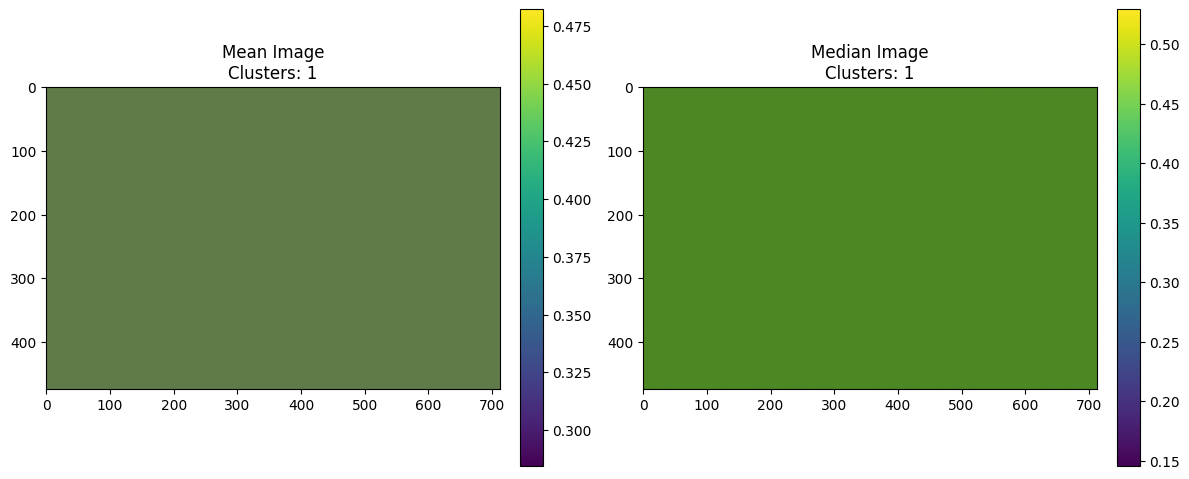

PSNR (mean): 9.84
PSNR (median): 9.46

Clustering: 2


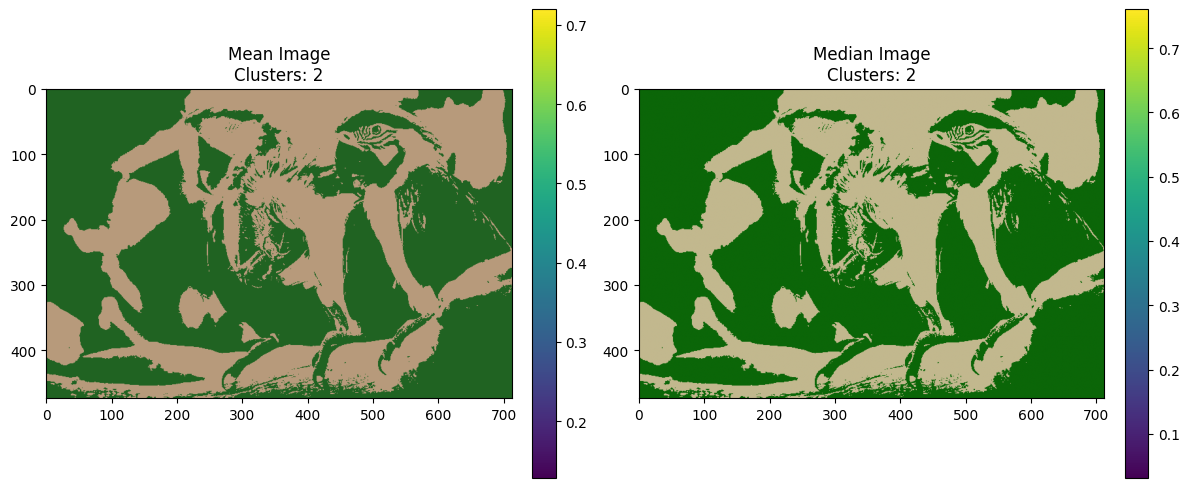

PSNR (mean): 12.11
PSNR (median): 11.69

Clustering: 3


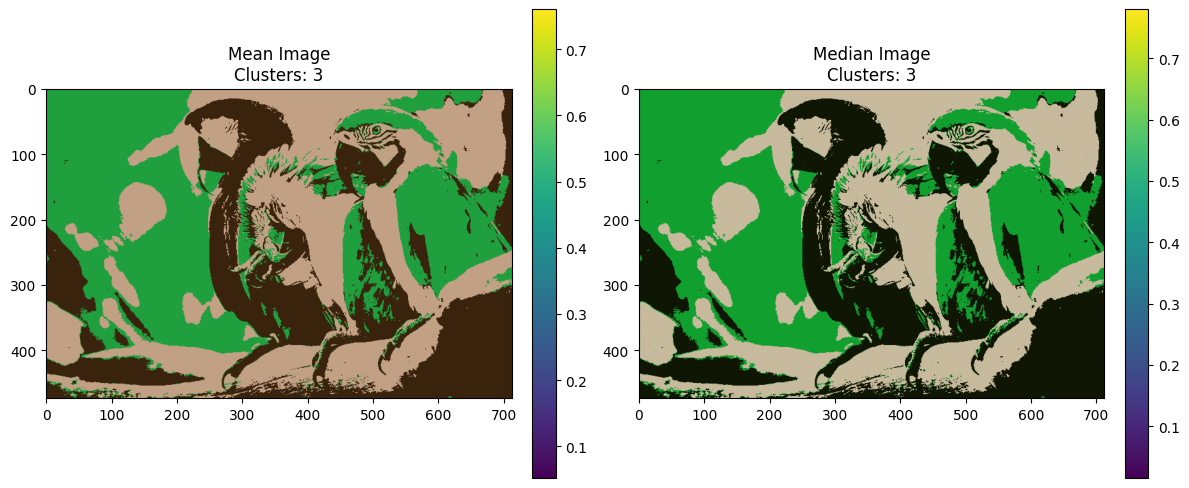

PSNR (mean): 13.17
PSNR (median): 12.63

Clustering: 4


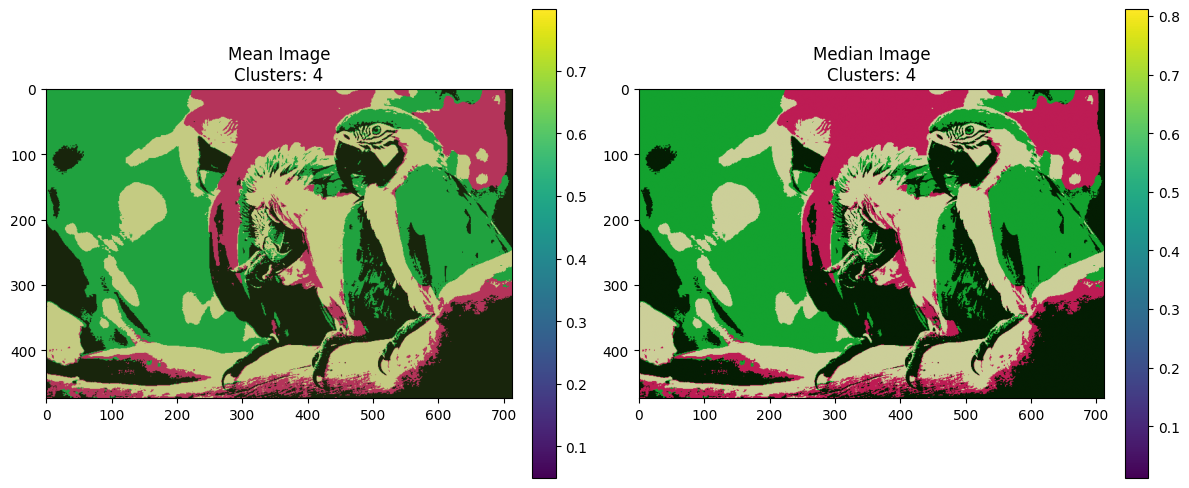

PSNR (mean): 14.32
PSNR (median): 14.00

Clustering: 5


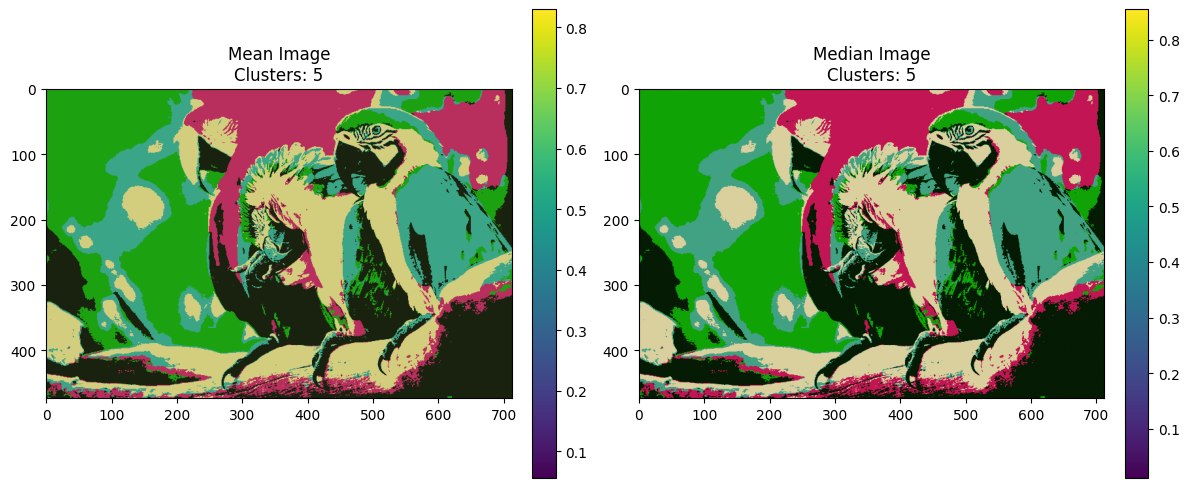

PSNR (mean): 15.09
PSNR (median): 14.69

Clustering: 6


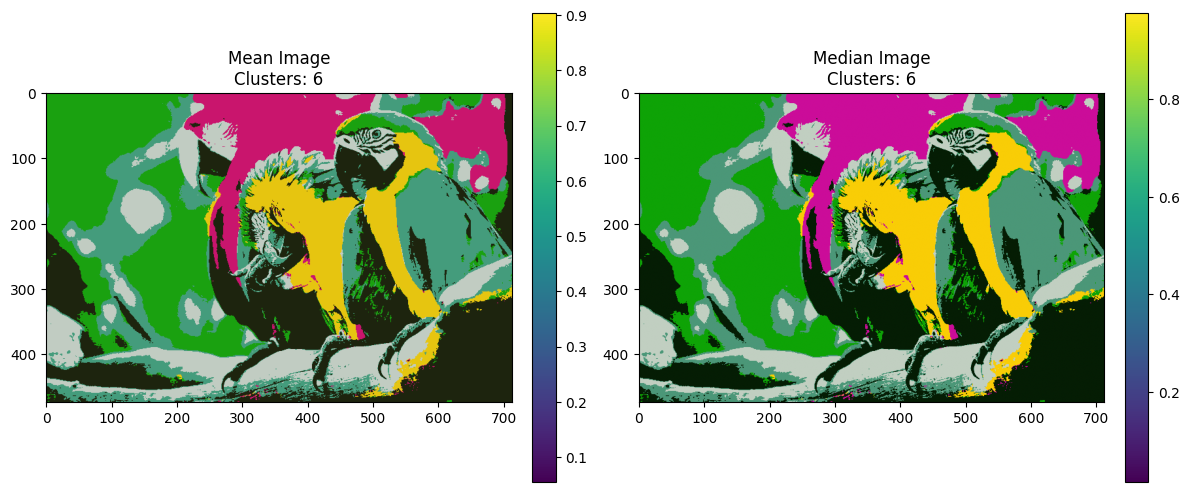

PSNR (mean): 16.57
PSNR (median): 16.07

Clustering: 7


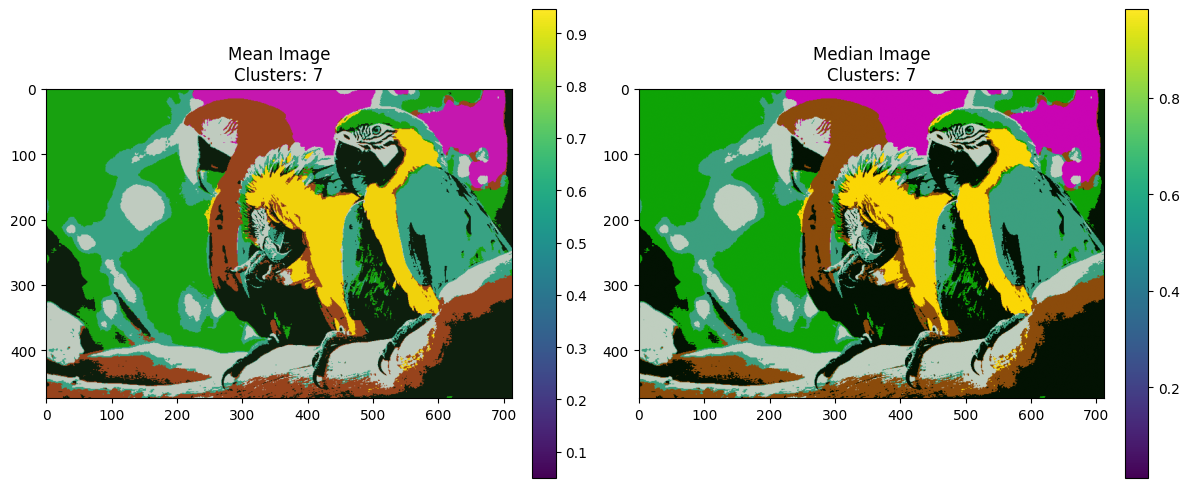

PSNR (mean): 17.67
PSNR (median): 17.37

Clustering: 8


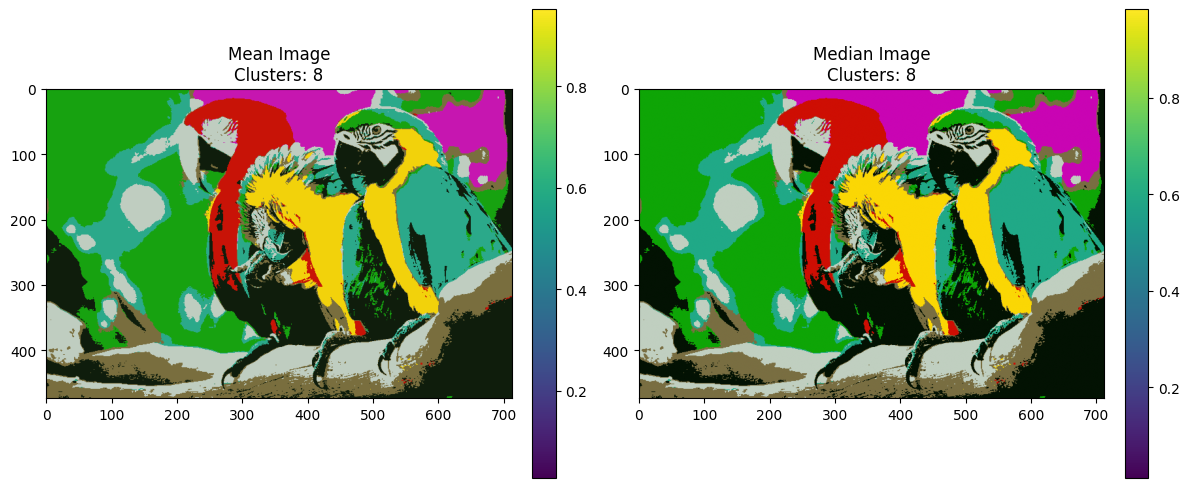

PSNR (mean): 18.38
PSNR (median): 18.10

Clustering: 9


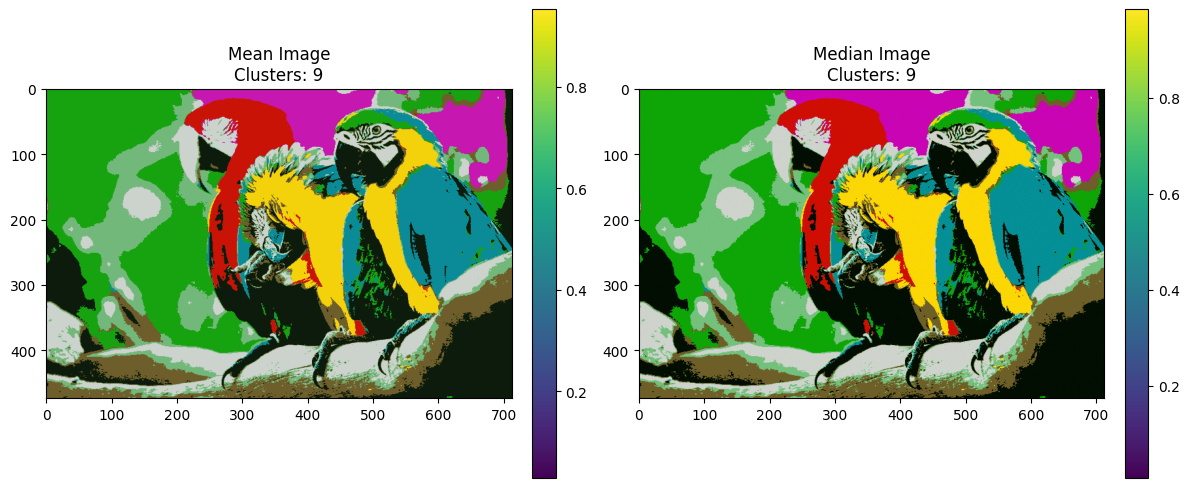

PSNR (mean): 19.14
PSNR (median): 18.84

Clustering: 10


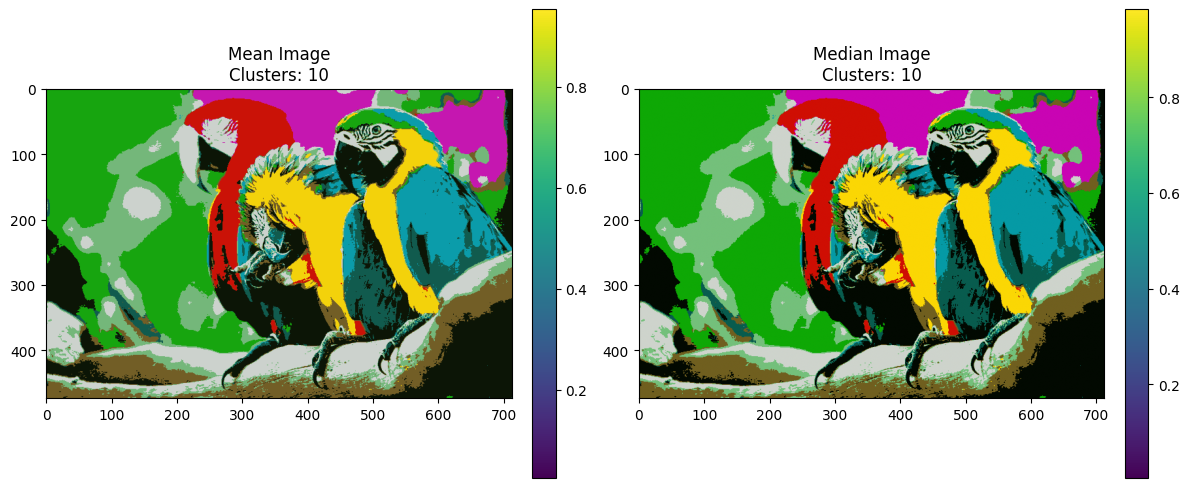

PSNR (mean): 19.54
PSNR (median): 19.23

Clustering: 11


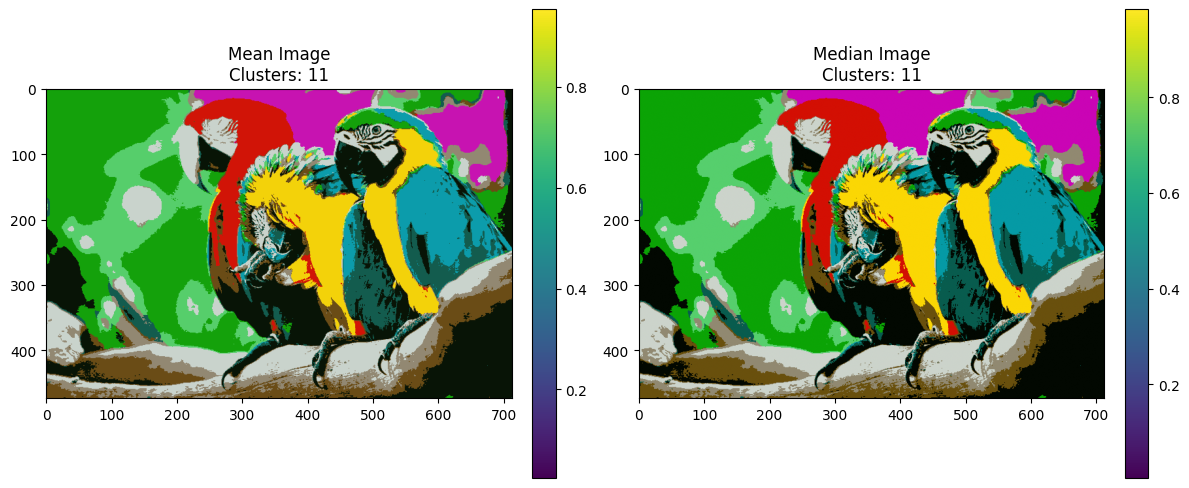

PSNR (mean): 20.08
PSNR (median): 19.83

 Condition met at 11 clusters!

Minimum clusters needed: 11


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

def evaluate_clustering_quality(pixels: np.ndarray, n_clusters_range: range = range(1, 21),
                              psnr_threshold: float = 20.0) -> int:

    for n_clusters in n_clusters_range:
        print(f"\n{'='*40}\nClustering: {n_clusters}\n{'='*40}")

        clustered_pixels = cluster_pixels(pixels.copy(), n_clusters)

        mean_img, median_img = mean_median_image(clustered_pixels)

        visualize_comparison(mean_img, median_img, n_clusters)

        psnr_mean = psnr(image, mean_img)
        psnr_median = psnr(image, median_img)

        print(f"PSNR (mean): {psnr_mean:.2f}")
        print(f"PSNR (median): {psnr_median:.2f}")

        if psnr_mean > psnr_threshold or psnr_median > psnr_threshold:
            print(f"\n Condition met at {n_clusters} clusters!")
            return n_clusters

    return -1

def visualize_comparison(mean_img: np.ndarray, median_img: np.ndarray, n_clusters: int) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for ax, img, title in [(ax1, mean_img, "Mean Image"),
                          (ax2, median_img, "Median Image")]:
        im = ax.imshow(img)
        ax.set_title(f"{title}\nClusters: {n_clusters}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

min_clusters = evaluate_clustering_quality(pixels)
print(f"\nMinimum clusters needed: {min_clusters}")